In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

In [2]:
data_path = "../Data/creditcard.csv"
df = pd.read_csv(data_path)

X = df.drop("Class", axis=1)
y = df["Class"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
 
    random_state=42,
    stratify=y
)

In [4]:
scaler = StandardScaler()

X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

In [5]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [6]:
rf_smote_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_smote_model.fit(X_train_smote, y_train_smote)

print("Random Forest With SMOTE Training Completed")

Random Forest With SMOTE Training Completed


In [7]:
y_pred_rf_smote = rf_smote_model.predict(X_test)

In [8]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf_smote))
print("Precision:", precision_score(y_test, y_pred_rf_smote))
print("Recall   :", recall_score(y_test, y_pred_rf_smote))
print("F1 Score :", f1_score(y_test, y_pred_rf_smote))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf_smote))

Accuracy : 0.9994557775359011
Precision: 0.845360824742268
Recall   : 0.8367346938775511
F1 Score : 0.841025641025641

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



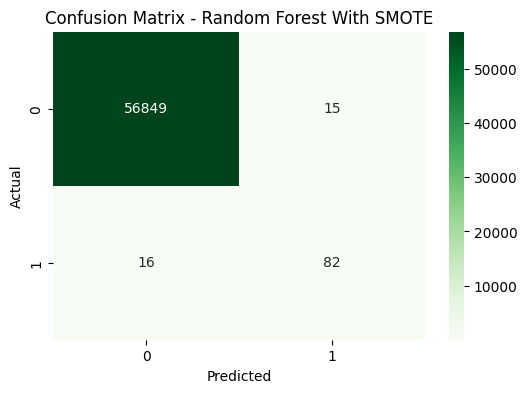

In [9]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf_smote),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix - Random Forest With SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 🌲 Random Forest Analysis (With SMOTE)

---

# 🧠 Objective

This notebook applies **SMOTE with Random Forest** to analyze whether balancing the training data improves fraud detection performance.

The goal is to compare whether Random Forest benefits from synthetic minority oversampling in the same way Logistic Regression did.

---

# 🔥 Class Distribution After SMOTE

## Before SMOTE

| Class         |  Count |
| ------------- | -----: |
| Non-Fraud (0) | 227451 |
| Fraud (1)     |    394 |

## After SMOTE

| Class         |  Count |
| ------------- | -----: |
| Non-Fraud (0) | 227451 |
| Fraud (1)     | 227451 |

SMOTE balanced the training dataset by generating synthetic fraud samples.

---

# 📊 Random Forest With SMOTE Results

| Metric       |  Score |
| ------------ | -----: |
| 🎯 Accuracy  | 99.95% |
| 🎯 Precision | 84.54% |
| 🔍 Recall    | 83.67% |
| ⚖️ F1 Score  | 84.10% |

---

# 🧩 Confusion Matrix Interpretation

| Actual / Predicted | Non-Fraud | Fraud |
| ------------------ | --------: | ----: |
| Non-Fraud          |     56849 |    15 |
| Fraud              |        16 |    82 |

---

# 📌 Important Observations

| Case               | Count |
| ------------------ | ----: |
| ✅ True Positives   |    82 |
| ✅ True Negatives   | 56849 |
| ⚠️ False Positives |    15 |
| ❌ False Negatives  |    16 |

---

# 🔥 Full Model Comparison

| Metric          | Logistic Regression Without SMOTE | Random Forest Without SMOTE | Logistic Regression With SMOTE | Random Forest With SMOTE |
| --------------- | --------------------------------: | --------------------------: | -----------------------------: | -----------------------: |
| Accuracy        |                            99.91% |                      99.96% |                         97.42% |                   99.95% |
| Precision       |                            82.89% |                      94.12% |                          5.80% |                   84.54% |
| Recall          |                            64.29% |                      81.63% |                         91.84% |                   83.67% |
| F1 Score        |                            72.41% |                      87.43% |                         10.92% |                   84.10% |
| False Positives |                                13 |                           5 |                           1461 |                       15 |
| False Negatives |                                35 |                          18 |                              8 |                       16 |

---

# 🧠 Interpretation of Random Forest With SMOTE

## 🎯 Accuracy = 99.95%

Random Forest with SMOTE maintained extremely high accuracy.

Unlike Logistic Regression with SMOTE, Random Forest did not suffer a large accuracy drop.

This shows that Random Forest handled the synthetic fraud samples more robustly.

---

## 🎯 Precision = 84.54%

Precision decreased compared to Random Forest without SMOTE:

| Model                       | Precision |
| --------------------------- | --------: |
| Random Forest Without SMOTE |    94.12% |
| Random Forest With SMOTE    |    84.54% |

This happened because SMOTE made the model slightly more sensitive toward fraud, increasing false positives.

| Model                       | False Positives |
| --------------------------- | --------------: |
| Random Forest Without SMOTE |               5 |
| Random Forest With SMOTE    |              15 |

So the model flagged more genuine transactions as fraud after SMOTE.

---

## 🔍 Recall = 83.67%

Recall improved slightly compared to Random Forest without SMOTE:

| Model                       | Recall |
| --------------------------- | -----: |
| Random Forest Without SMOTE | 81.63% |
| Random Forest With SMOTE    | 83.67% |

False Negatives reduced from:

```text
18 → 16
```

This means SMOTE helped Random Forest detect 2 additional fraud cases.

However, the improvement was small compared to Logistic Regression with SMOTE.

---

## ⚖️ F1 Score = 84.10%

F1 Score slightly decreased compared to Random Forest without SMOTE:

| Model                       | F1 Score |
| --------------------------- | -------: |
| Random Forest Without SMOTE |   87.43% |
| Random Forest With SMOTE    |   84.10% |

This happened because the small Recall improvement was not enough to compensate for the Precision drop.

---

# 🧠 Key Insight

For Logistic Regression, SMOTE caused a major shift:

* Recall increased strongly
* Precision collapsed heavily
* False positives increased dramatically

For Random Forest, SMOTE had a smaller effect:

* Recall improved slightly
* Precision decreased moderately
* False positives increased slightly
* Overall performance remained strong

This shows that **SMOTE does not affect every algorithm in the same way**.

---

# 🏆 Best Overall Model So Far

Based on the current results:

| Priority               | Best Model                     |
| ---------------------- | ------------------------------ |
| Highest Accuracy       | Random Forest Without SMOTE    |
| Highest Precision      | Random Forest Without SMOTE    |
| Highest Recall         | Logistic Regression With SMOTE |
| Highest F1 Score       | Random Forest Without SMOTE    |
| Lowest False Negatives | Logistic Regression With SMOTE |
| Lowest False Positives | Random Forest Without SMOTE    |

---

# ⚖️ Final Tradeoff Analysis

## 🔥 Logistic Regression With SMOTE

Best for catching the maximum number of fraud cases.

However, it produces too many false alarms.

```text
False Positives = 1461
False Negatives = 8
```

---

## 🌲 Random Forest Without SMOTE

Best overall balance so far.

It has strong Precision, Recall, and F1 Score without using synthetic oversampling.

```text
False Positives = 5
False Negatives = 18
```

---

## 🌲 Random Forest With SMOTE

Improves Recall slightly compared to Random Forest without SMOTE.

But this comes at the cost of lower Precision and more false positives.

```text
False Positives increased from 5 to 15
False Negatives reduced from 18 to 16
```

---

# 🚀 Final Understanding

This experiment shows that **SMOTE is not automatically better for every model**.

For Logistic Regression, SMOTE greatly improved fraud detection sensitivity but caused too many false positives.

For Random Forest, SMOTE gave only a small Recall improvement while slightly reducing overall balance.

Therefore, based on current results:

# 🌲 Random Forest Without SMOTE is the strongest balanced model so far.

However, if the business priority is to catch as many frauds as possible, Logistic Regression With SMOTE may still be useful after threshold tuning and false positive control.
